In [22]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import PassManager
import lovelyplots  # noqa: F401
import scienceplots  # noqa: F401
import time
import matplotlib.pyplot as plt
from qiskit.synthesis import XXDecomposer
from qiskit.converters import circuit_to_dag
from qiskit.dagcircuit import DAGCircuit
from qiskit.transpiler.basepasses import TransformationPass
from gulps import GulpsDecompositionPass
from gulps import GulpsDecomposer
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from qiskit.circuit.random import random_circuit
from gulps.config import GulpsConfig
from gulps.core.isa import DiscreteISA

## 1) Tutorial / demo: run GULPS as a TransformationPass
This section sets up `gulps_pm`, runs it on a small circuit, and visualizes the output circuit.

In [23]:
isa = [
    (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=False)
decomposer = GulpsDecomposer(isa=isa, config_options=GulpsConfig())


gulps_pm = PassManager(
    [
        GulpsDecompositionPass(decomposer),
        Optimize1qGatesDecomposition(basis="u3"),
    ]
)

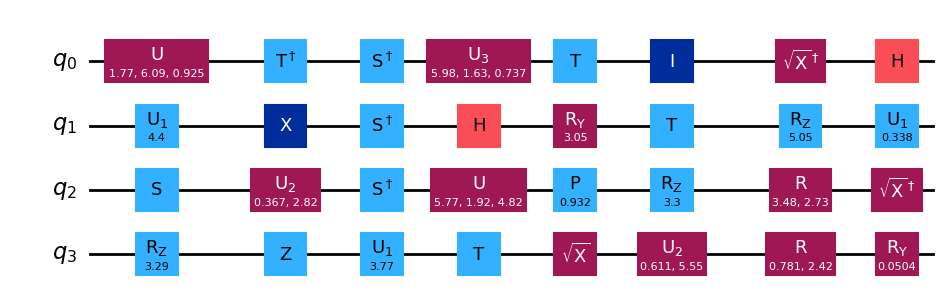

In [24]:
input_qc = random_circuit(4, 8, max_operands=2)
input_qc.draw("mpl")

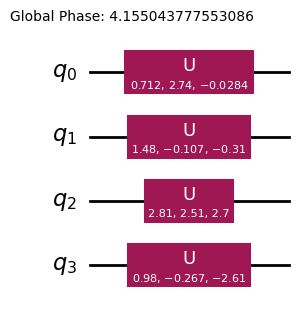

In [25]:
output_qc = gulps_pm.run(input_qc)
output_qc.draw("mpl")

Runtime vs ISA: GULPS vs XXDecomposer pass

In [26]:
# Runtime vs ISA: GULPS pass vs ad-hoc XX pass

N = 1000
SEED0 = 0

ISA_TIERS = {
    "cx": [1.0],
    "sq2cx": [1 / 2],
    "sq3cx": [1 / 3],
    "sq4cx": [1 / 4],
    "sq4cx+sq3cx": [1 / 4, 1 / 3],
    "sq4cx+sq2cx": [1 / 4, 1 / 2],
    "sq4cx+sq3cx+sq2cx": [1 / 4, 1 / 3, 1 / 2],
    "sq4cx+sq3cx+sq2cx+cx": [1 / 4, 1 / 3, 1 / 2, 1.0],
}

# Modeling choice for XXDecomposer fairness:
# If GULPS cost is linear in fractional power p, use fidelity so that -log(F_p) ∝ p.
# With a reference full-CX fidelity F_1, set F_p = F_1**p.
FULL_CX_INFIDELITY = 1e-10


class XXDecompositionPass(TransformationPass):
    """Ad-hoc XX pass, matching GulpsDecompositionPass style."""

    def __init__(self, decomposer):
        super().__init__()
        self._decomposer = decomposer

    def run(self, dag: DAGCircuit) -> DAGCircuit:
        for node in dag.op_nodes():
            if (
                node.op.num_qubits != 2
                or node.is_parameterized()
                or (not hasattr(node.op, "to_matrix"))
            ):
                continue
            decomposed = self._decomposer(Operator(node.op))
            dag.substitute_node_with_dag(node, circuit_to_dag(decomposed))
        return dag


def _summarize(times):
    arr_ms = np.array(times) * 1000.0
    return {
        "total_ms": float(np.sum(arr_ms)),
        "mean_ms": float(np.mean(arr_ms)) if len(arr_ms) else None,
        "p95_ms": float(np.percentile(arr_ms, 95)) if len(arr_ms) else None,
    }


def _xx_basis_fidelity_from_linear_cost(powers, full_cx_infidelity=FULL_CX_INFIDELITY):
    f1 = 1.0 - full_cx_infidelity
    strengths = [p * (np.pi / 2) for p in powers]
    basis_fidelity = {
        s: float(np.clip(f1**p, 0.0, 1.0)) for s, p in zip(strengths, powers)
    }
    return basis_fidelity


def _build_pass_managers(powers):
    basis_fidelity = _xx_basis_fidelity_from_linear_cost(powers)

    gulps_dec = GulpsDecomposer(
        gate_set=[CXGate().power(p) for p in powers],
        costs=powers,
        names=[f"cx^{p}" for p in powers],
        config_options=GulpsConfig(max_depth=12),
    )
    xx_dec = XXDecomposer(basis_fidelity)

    gulps_passes = [GulpsDecompositionPass(gulps_dec)]
    xx_passes = [XXDecompositionPass(xx_dec)]

    return PassManager(gulps_passes), PassManager(xx_passes)


def _bench_pm(pm, targets):
    times = []
    fids = []
    fails = 0
    for u in targets:
        qc = QuantumCircuit(2)
        qc.append(UnitaryGate(Operator(u)), [0, 1])
        try:
            t0 = time.perf_counter()
            out = pm.run(qc)
            times.append(time.perf_counter() - t0)
            fids.append(average_gate_fidelity(u, Operator(out)))
        except Exception:
            fails += 1
    return times, fids, fails


def run_experiment(n=N, seed0=SEED0):
    targets = [random_unitary(4, seed=seed) for seed in range(seed0, seed0 + n)]
    rows = []

    for isa_name, powers in ISA_TIERS.items():
        gulps_pm_isa, xx_pm_isa = _build_pass_managers(powers)

        g_t, g_f, g_fail = _bench_pm(gulps_pm_isa, targets)
        x_t, x_f, x_fail = _bench_pm(xx_pm_isa, targets)

        g = _summarize(g_t)
        x = _summarize(x_t)
        ratio = g["total_ms"] / x["total_ms"]

        print(f"\n{isa_name} (n={n})")
        print(
            f"  gulps: total={g['total_ms']:.1f} ms  ok={n - g_fail}/{n}  fid_min={min(g_f):.8f}"
        )
        print(
            f"  xx   : total={x['total_ms']:.1f} ms  ok={n - x_fail}/{n}  fid_min={min(x_f):.8f}"
        )
        print(f"  ratio gulps/xx total: {ratio:.3f}x")

        rows.append(
            {
                "isa": isa_name,
                "gulps_total_ms": g["total_ms"],
                "xx_total_ms": x["total_ms"],
                "ratio_total": ratio,
                "gulps_ok": n - g_fail,
                "xx_ok": n - x_fail,
                "gulps_fid_min": float(min(g_f)) if g_f else None,
                "xx_fid_min": float(min(x_f)) if x_f else None,
            }
        )

    return rows

In [27]:
results = run_experiment(n=N, seed0=SEED0)


cx (n=1000)
  gulps: total=2155.4 ms  ok=1000/1000  fid_min=1.00000000
  xx   : total=2617.7 ms  ok=1000/1000  fid_min=1.00000000
  ratio gulps/xx total: 0.823x

sq2cx (n=1000)
  gulps: total=4761.9 ms  ok=1000/1000  fid_min=1.00000000
  xx   : total=3093.3 ms  ok=1000/1000  fid_min=1.00000000
  ratio gulps/xx total: 1.539x

sq3cx (n=1000)
  gulps: total=3968.5 ms  ok=999/1000  fid_min=1.00000000
  xx   : total=4632.4 ms  ok=1000/1000  fid_min=0.99996233
  ratio gulps/xx total: 0.857x

sq4cx (n=1000)
  gulps: total=4842.0 ms  ok=1000/1000  fid_min=1.00000000
  xx   : total=5743.4 ms  ok=1000/1000  fid_min=0.99994134
  ratio gulps/xx total: 0.843x

sq4cx+sq3cx (n=1000)
  gulps: total=6030.5 ms  ok=999/1000  fid_min=1.00000000
  xx   : total=6970.0 ms  ok=1000/1000  fid_min=0.99994134
  ratio gulps/xx total: 0.865x

sq4cx+sq2cx (n=1000)
  gulps: total=3894.9 ms  ok=997/1000  fid_min=1.00000000
  xx   : total=6786.1 ms  ok=1000/1000  fid_min=0.99994134
  ratio gulps/xx total: 0.574x

sq4

[{'isa': 'cx',
  'gulps_total_ms': 2155.384171725018,
  'xx_total_ms': 2617.6887610636186,
  'ratio_total': 0.8233920715804437,
  'gulps_ok': 1000,
  'xx_ok': 1000,
  'gulps_fid_min': 0.9999999998056215,
  'xx_fid_min': 0.9999999999991349},
 {'isa': 'sq2cx',
  'gulps_total_ms': 4761.890474910615,
  'xx_total_ms': 3093.3456787024625,
  'ratio_total': 1.539398104678699,
  'gulps_ok': 1000,
  'xx_ok': 1000,
  'gulps_fid_min': 0.99999999967365,
  'xx_fid_min': 0.9999999999994152},
 {'isa': 'sq3cx',
  'gulps_total_ms': 3968.4559588495176,
  'xx_total_ms': 4632.404258940369,
  'ratio_total': 0.8566730658686673,
  'gulps_ok': 999,
  'xx_ok': 1000,
  'gulps_fid_min': 0.9999999996693372,
  'xx_fid_min': 0.9999623292869227},
 {'isa': 'sq4cx',
  'gulps_total_ms': 4841.953544178978,
  'xx_total_ms': 5743.384583067382,
  'ratio_total': 0.8430488110536776,
  'gulps_ok': 1000,
  'xx_ok': 1000,
  'gulps_fid_min': 0.9999999999726998,
  'xx_fid_min': 0.9999413418981937},
 {'isa': 'sq4cx+sq3cx',
  'gulps

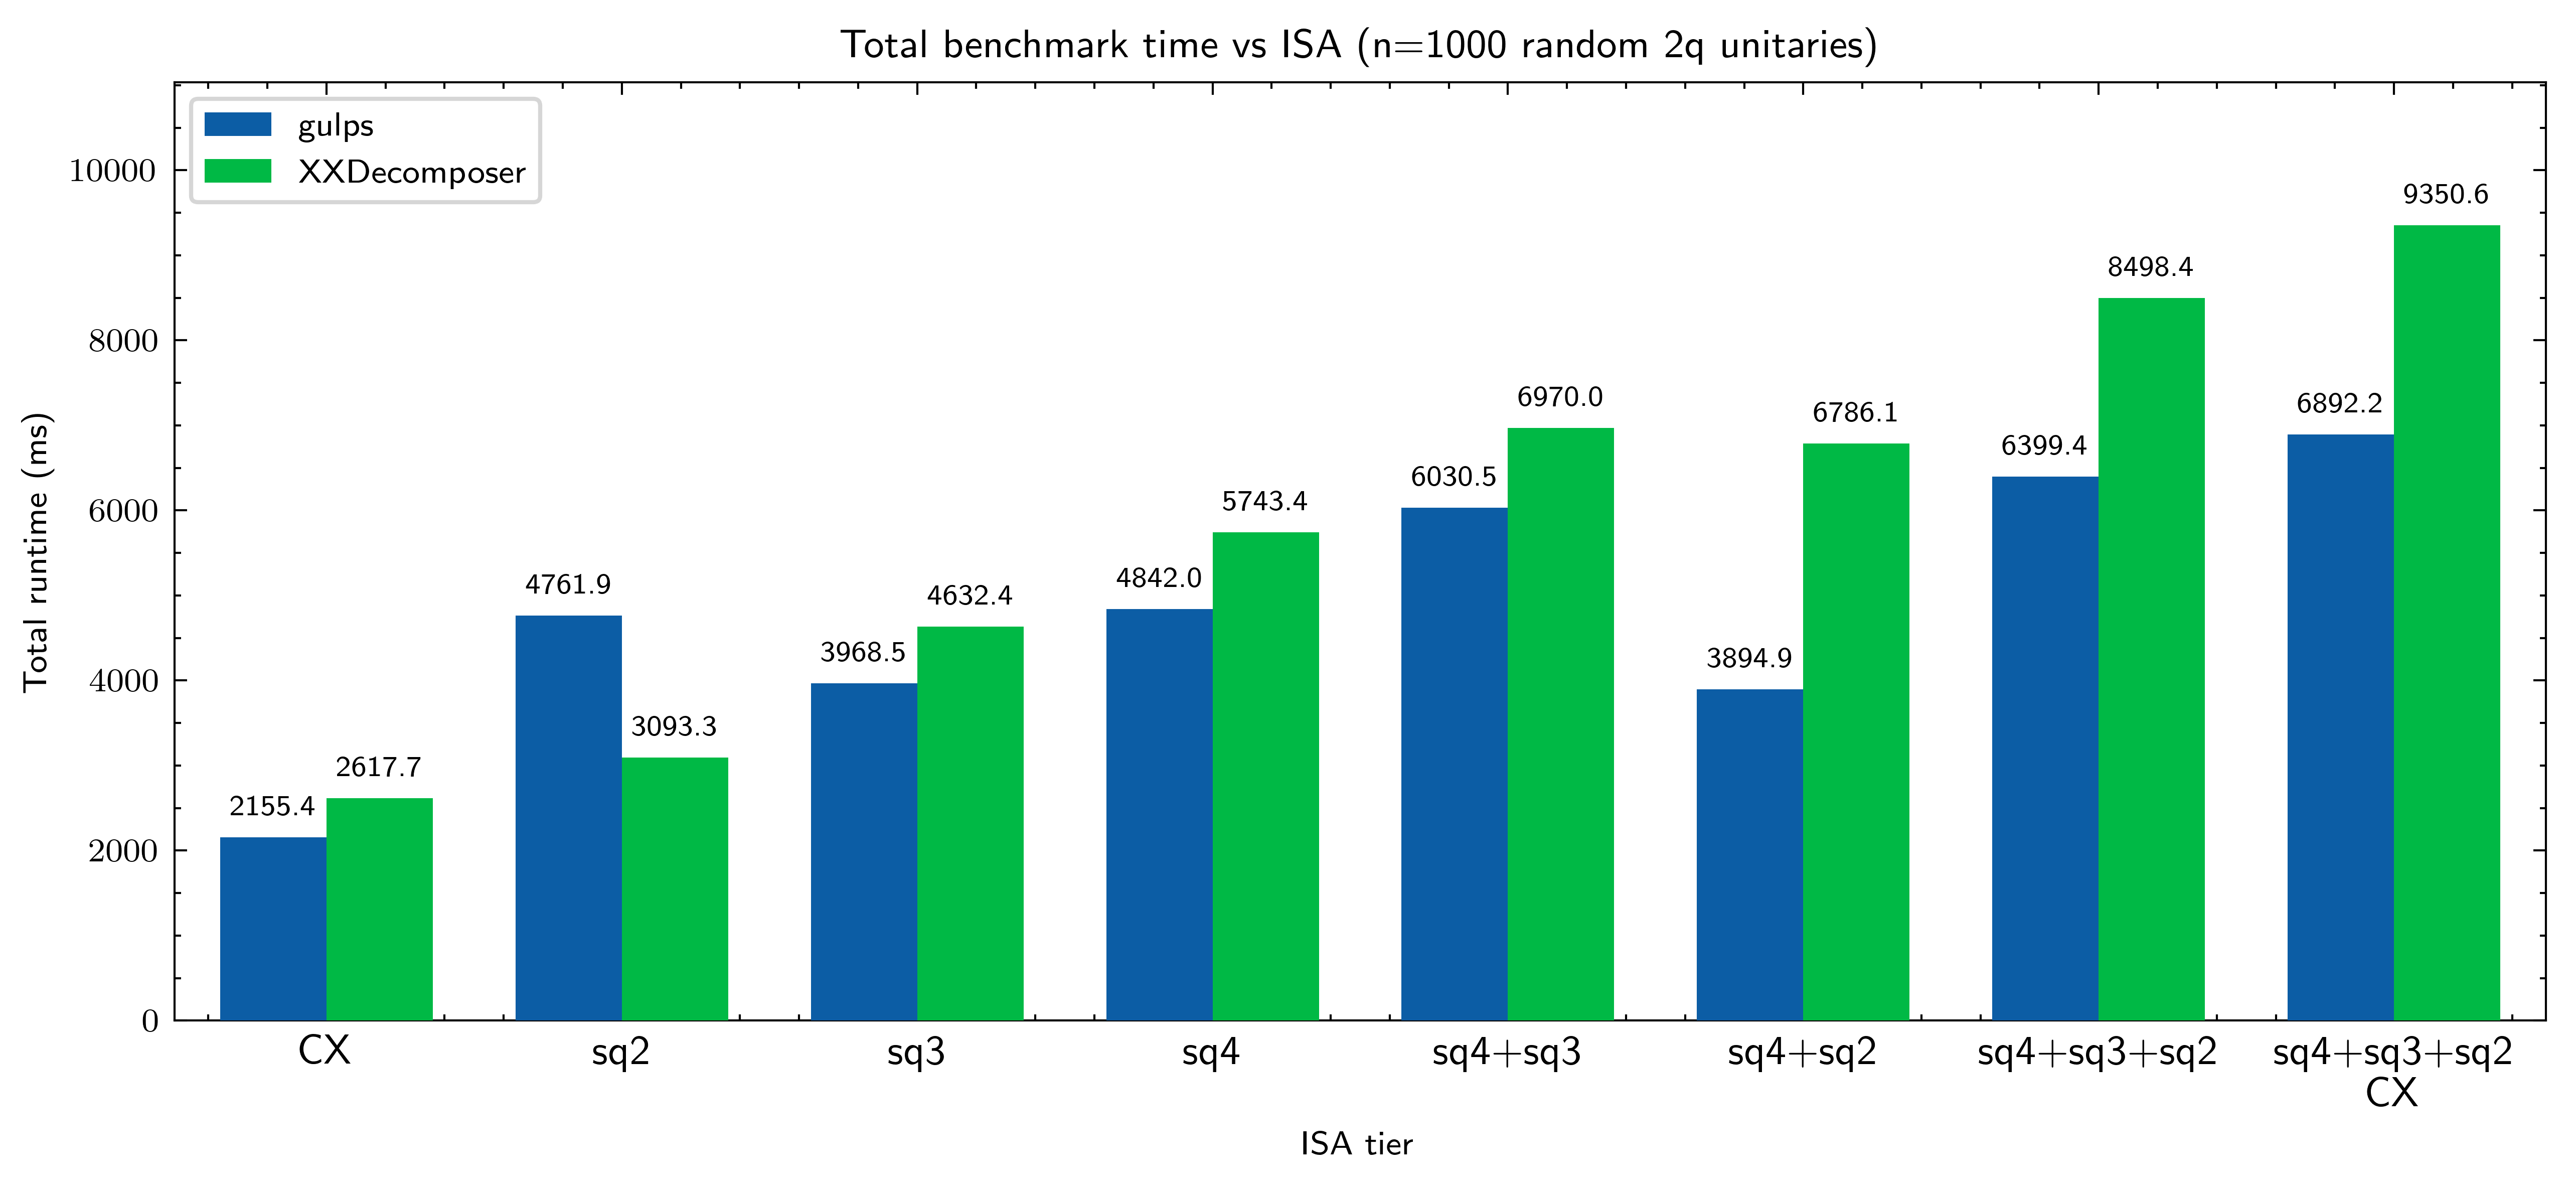

In [28]:
def _pretty_isa_label(name):
    parts = []
    for token in name.split("+"):
        token = token.strip().lower()
        if token == "cx":
            parts.append("CX")
            continue

        if token.startswith("sq") and token.endswith("cx"):
            n_str = token[2:-2]
            if n_str.isdigit() and int(n_str) > 1:
                parts.append(f"sq{int(n_str)}")
                continue

        parts.append(token.upper())

    chunks = ["+".join(parts[i : i + 3]) for i in range(0, len(parts), 3)]
    return "\n".join(chunks)


def plot_runtime_bars(rows):
    labels = [_pretty_isa_label(r["isa"]) for r in rows]
    gulps = [r["gulps_total_ms"] for r in rows]
    xx = [r["xx_total_ms"] for r in rows]

    x = np.arange(len(labels))
    w = 0.36

    with plt.style.context(["ieee", "science", "use_mathtext"]):
        fig, ax = plt.subplots(figsize=(8.6, 4.0))
        bars_g = ax.bar(
            x - w / 2,
            gulps,
            width=w,
            label="gulps",
            linewidth=0.6,
            zorder=3,
        )
        bars_x = ax.bar(
            x + w / 2,
            xx,
            width=w,
            label="XXDecomposer",
            linewidth=0.6,
            zorder=3,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0, ha="center")
        ax.tick_params(axis="x", labelsize=10)
        ax.margins(x=0.02)
        ax.set_ylabel("Total runtime (ms)")
        ax.set_xlabel("ISA tier")
        ax.set_title(f"Total benchmark time vs ISA (n={N} random 2q unitaries)")
        ax.legend(frameon=True, loc="upper left")

        ymax = max(max(gulps), max(xx))
        ax.set_ylim(0, ymax * 1.18)

        for bars in (bars_g, bars_x):
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + ymax * 0.02,
                    f"{h:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

        plt.tight_layout()
    return fig


fig = plot_runtime_bars(results)
results